# Import Functions

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.utils import resample

In [58]:
import statsmodels.api as sm
import bambi as bmb
import arviz as az

# Pull Data

In [59]:
from ucimlrepo import fetch_ucirepo
energy_efficiency = fetch_ucirepo(id=242) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 
  
# metadata 
print(energy_efficiency.metadata) 
  
# variable information 
print(energy_efficiency.variables) 

{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

In [60]:
X.columns = [
    'relative_compactness',
    'surface_area',
    'wall_area',
    'roof_area',
    'overall_height',
    'orientation',
    'glazing_area',
    'glazing_area_distribution',
]
X

,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0
...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5


For this problem, let us focus on Heating Load alone, which is Y1.

In [61]:
y = y['Y1']

# Exploratory Data Analysis (EDA)

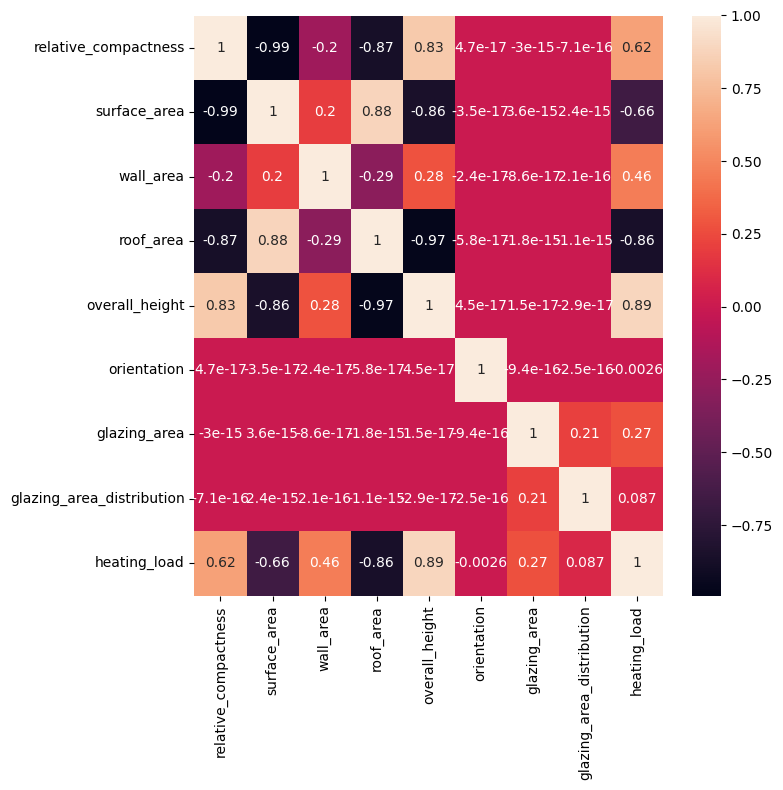

In [62]:
df_corr = X.copy()
df_corr['heating_load'] = y
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(df_corr.corr(), annot=True, ax=ax, square=False)
plt.tight_layout()

Based on the 8 predictor variables, we can see that relative_compactness, wall_area, overall_height, glazing_area, and glazing_area_distribution have positive correlation on the heating_load while surface_area, roof_area, and orientation (albeit small) has negative correlation.

It can also be seen that there is a strong absolute correlation between the 4 predictor variables:
- surface_area
- relative_compactness
- overall_height
- roof_area

Out of the 4, overall_height has the highest correlation with heating_load which is our target variable. Therefore, we will drop the other variables. This will ensure that multicollinearity will not be an issue. By mitigating multicollinearity, we avoid unstable regression coefficients as this is somewhat related to features that closely become linearly dependent.

In [65]:
X = X.drop(columns=['surface_area', 'relative_compactness', 'roof_area'])
X

,wall_area,overall_height,orientation,glazing_area,glazing_area_distribution
0,294.0,7.0,2,0.0,0
1,294.0,7.0,3,0.0,0
2,294.0,7.0,4,0.0,0
3,294.0,7.0,5,0.0,0
4,318.5,7.0,2,0.0,0
...,...,...,...,...,...
763,343.0,3.5,5,0.4,5
764,367.5,3.5,2,0.4,5
765,367.5,3.5,3,0.4,5
766,367.5,3.5,4,0.4,5


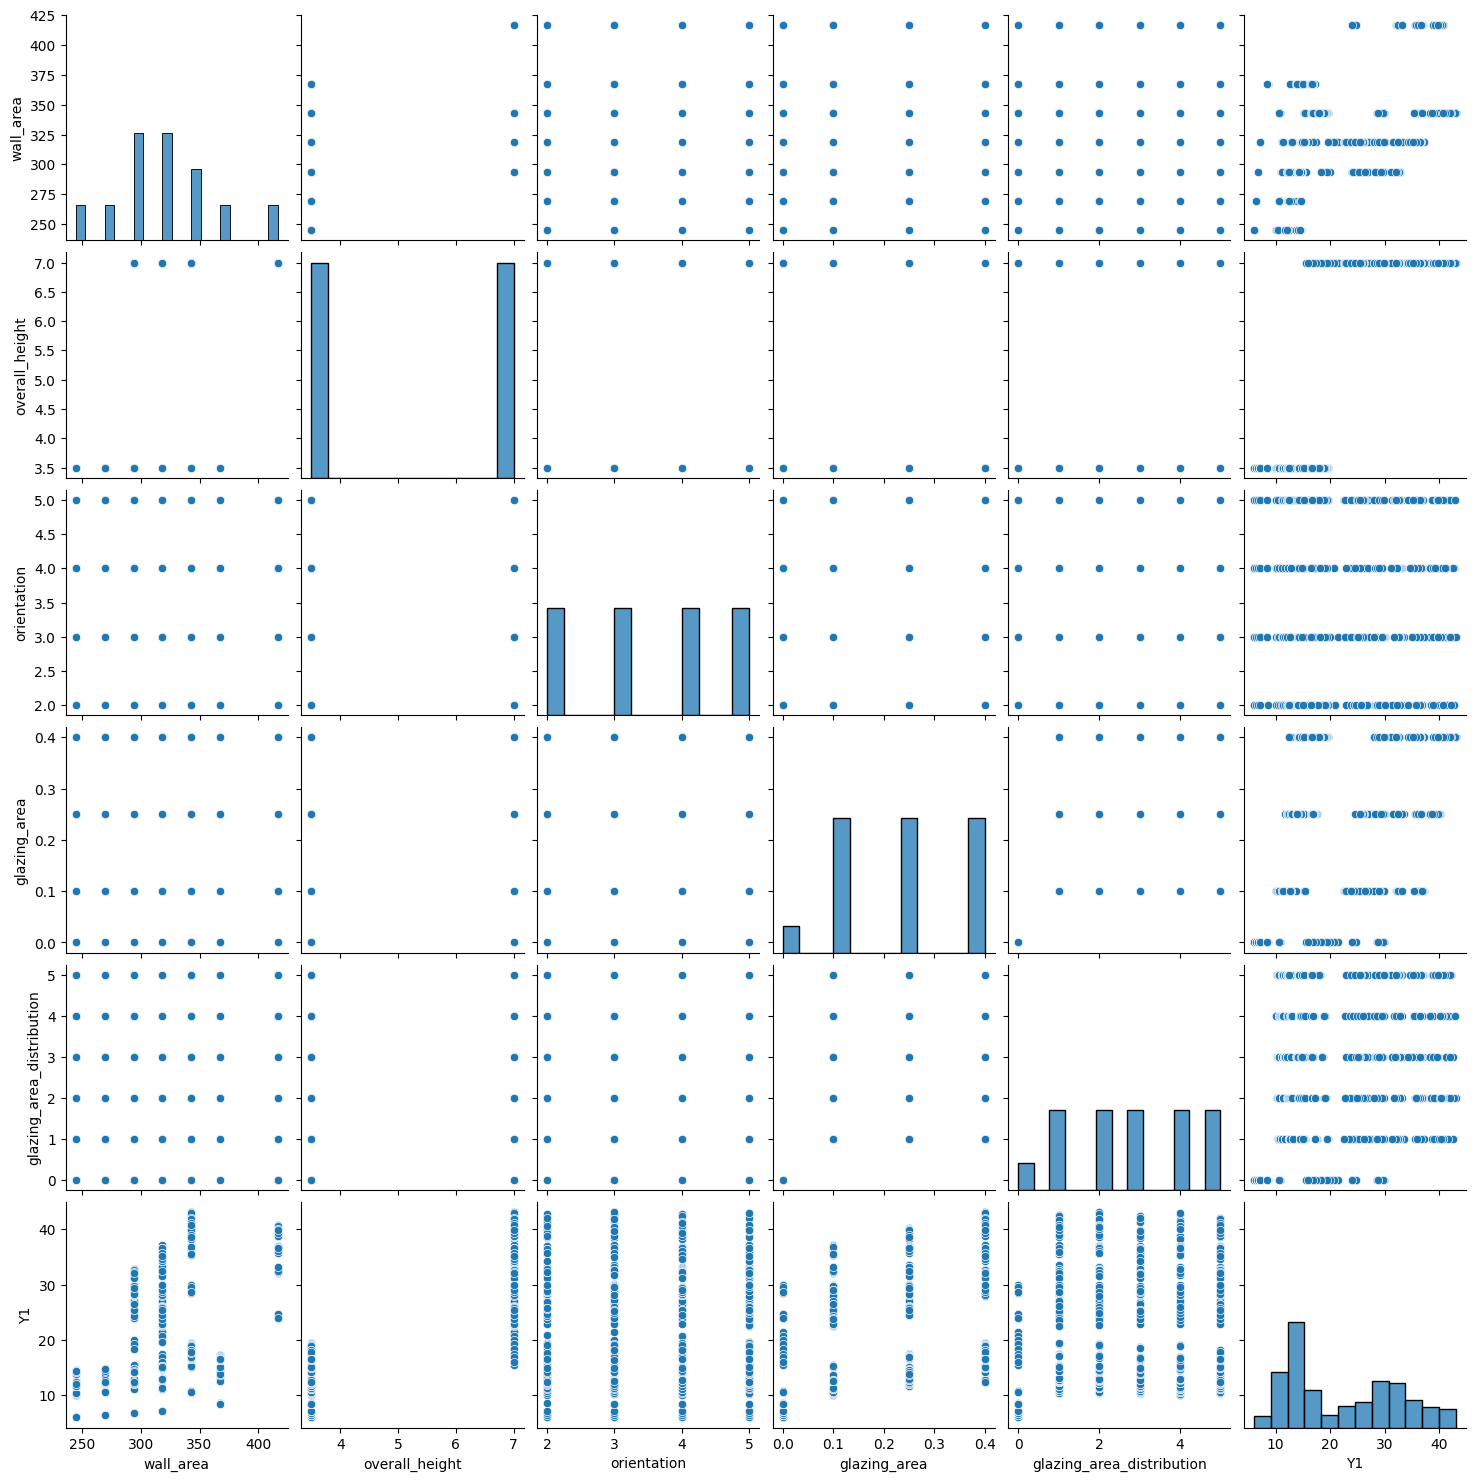

In [66]:
sns.pairplot(pd.concat([X, y]))

What we noticed here is that the data looks discrete, specifically for overall_height, orientation, and glazing_area. While we may pass them as categorical data, instead, we will consider them as continuous for this study for a simplified analysis.

Normalize data using Standard Scaler (shift to zero mean and scale to unit variance) to ensure that large variables will drown small variables. This also makes sure that the coefficients calculated later can be interpreted.

In [11]:
standardscaler = StandardScaler().set_output(transform='pandas')
X = standardscaler.fit_transform(X)
X = sm.add_constant(X)

# Ordinary Least Squares (OLS) Regression

Fit the model on the training data and shown here are the parameters. It can be seen that if our features of our samples has mean values, then its value is the constant ~22.3. Based on the parameters also, overall_height has the highest impact on prediction while orientation has negligible effect. But are these statistically significant? This can be seen later based on the p-values. A low p-value means that the features have a significant impact for prediction while a p-value above the $\alpha$ means that the feature has no statistical impact.

In [12]:
model_ols = sm.OLS(y, X).fit()
model_ols.params

const                        22.307201
wall_area                     2.252677
overall_height                8.335737
orientation                  -0.026082
glazing_area                  2.653714
glazing_area_distribution     0.315836
dtype: float64

Predicting on the train data.

In [13]:
y_pred = model_ols.predict(exog=X)

In [14]:
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("RMSE:", rmse)
print("R2: ", r2)

RMSE: 3.011416315149754
R2:  0.9108116206675553


The prediction's RMSE and R-squared are 3.01 and 0.91 respectively. This can be imagined as having the an average error of around 3 units of heating load and 91% of the variation of the heating load can be explained by our features.

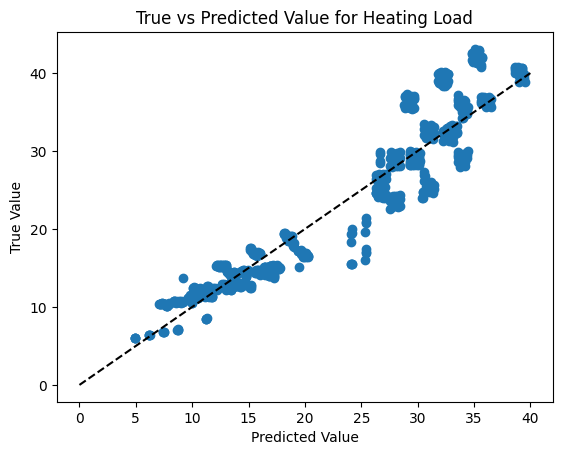

In [15]:
plt.scatter(y_pred, y)
plt.plot([0, 40], [0, 40], 'k--')
plt.xlabel('Predicted Value')
plt.ylabel('True Value')
plt.title('True vs Predicted Value for Heating Load')
plt.show();

Shown in plot is the true value vs predicted value. The perfect prediction is when the predicted value matches exactly the true value. Perfect predictions will fall along the 45 degree broken line. The farther the data points are from the 45 degree line, the more error the prediction has.

Disclaimer: While the accepted practice in ML is to fit the model on training data and predict on test data, for this exercise, we will fit on the whole data and then predict on the whole data.

In [16]:
model_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     Y1   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.910
Method:                 Least Squares   F-statistic:                     1556.
Date:                Fri, 06 Jun 2025   Prob (F-statistic):               0.00
Time:                        09:37:31   Log-Likelihood:                -1936.4
No. Observations:                 768   AIC:                             3885.
Df Residuals:                     762   BIC:                             3913.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        22.3072      0.109    204.480      0.000      22.093      22.521
wall_area                     2.2527      0.114     19.817      0.000       2.030       2.476
overall_height                8.3357      0.114     73.332      0.000       8.113       8.559
orientation                  -0.0261      0.109     -0.239      0.811      -0.240       0.188
glazing_area                  2.6537      0.112     23.767      0.000       2.435       2.873
glazing_area_distribution     0.3158      0.112      2.829      0.005       0.097       0.535
==============================================================================
Omnibus:                       29.729   Durbin-Watson:                   0.595
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               47.508
Skew:                           0.312   Prob(JB):                     4.83e-11
Kurtosis:                       4.047   Cond. No.                         1.33
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

We can see in this summary table the coefficients of the different predictor variables. Shown in the last two columns are the lower and higher confidence interval for confidence level 0.05. If p-value is higher than 0.05, then they are not significant in the prediction. Other than the bias being ~22.3, we can see that the overall height has the heighest impact on when predicting the heating_load with coefficient of ~8.3 while orientation has the lowest impact. According to the p-value, orientation is not statistically significant in helping predicting heating_load. This is based on confidence level of 95%.

# Bayesian Regression with Non-Informative Prior

Create a dataframe copy.

In [17]:
df_bayes_nip = X.copy()
df_bayes_nip['y'] = y

Below, we will create a prior for the intercept (the bias term) and for the other features. The prior is a normal distribution centered around 0 with a very large variance. This prior is almost very flat due to the large variance. Thus, this is a non-informative prior as it doesn't provide a specific initial belief.

In [18]:
nip_priors = {"Intercept": bmb.Prior("Normal", mu=0, sigma=1000)}
for col in X.columns:
    nip_priors[col] = bmb.Prior("Normal", mu=0, sigma=1000)

We will generate a model with this model incorporating our initial belief.

In [19]:
model_nip = bmb.Model("y ~ " + " + ".join(X.columns[1:]), data=df_bayes_nip, priors=nip_priors)

The model uses Markov Chain Monte Carlo under the hood for training. This works by simulating a smart random walk and sample different coefficient values. A tune of 1000 can be thought of as initial samples of coefficients that are unstable and in this case are discareded. The next draw of 2000 are the "fine-tuned" samples of coefficients that are much better and are collected--these are the final posterior. Target accept controls how cautious the sample should be.

In [20]:
idata_nip = model_nip.fit(draws=2000, tune=1000, random_seed=42, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
c:\Users\Deomary\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytensor\link\c\cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, wall_area, overall_height, orientation, glazing_area, glazing_area_distribution]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


In [21]:
az_summary_nip = az.summary(idata_nip, hdi_prob=0.95)
display(az_summary_nip)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.029,0.077,2.882,3.183,0.001,0.001,11759.0,5809.0,1.0
Intercept,22.309,0.109,22.100,22.524,0.001,0.001,12109.0,4585.0,1.0
wall_area,2.252,0.114,2.036,2.479,0.001,0.001,11274.0,6390.0,1.0
overall_height,8.336,0.114,8.103,8.549,0.001,0.001,12800.0,6388.0,1.0
orientation,-0.027,0.110,-0.235,0.187,0.001,0.001,12182.0,6106.0,1.0
glazing_area,2.653,0.112,2.443,2.883,0.001,0.001,13179.0,6273.0,1.0
glazing_area_distribution,0.315,0.111,0.102,0.540,0.001,0.001,12893.0,6205.0,1.0


Here is the summary of the model's coefficients. Mean represents the posterior mean and is the equivalent of the actual coefficient in an OLS regression. The sd is the standard deviation of the posterior. The hdi_2.5% and hdi_97.5% are the interval (analogous to confidence interval) for 95% credibility--HDI means highest density interval. mcse_mean is the Monte Carlo Standard Error of the Mean and is the standard error of the sampling of the 2000 draws. mcse_sd is the stadard deviation of the Monte Carlo Standard Error. ess_bulk is the Effective Sample Size - Bulk which is a measure of how many samples we have effectively after accounting for autocorrelation; a rule of thumb is >1000 is excellent. ess_tail is similar to ess_bulk but checks for the tails. Lastly. r_hat is a measure of convergence where 1.0 is ideal.

For our case, however, only the mean, hdi_2.5% and hdi_97.5% are used for the analysis as these have a direct counterpart with the OLS.

c:\Users\Deomary\AppData\Local\Programs\Python\Python312\Lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


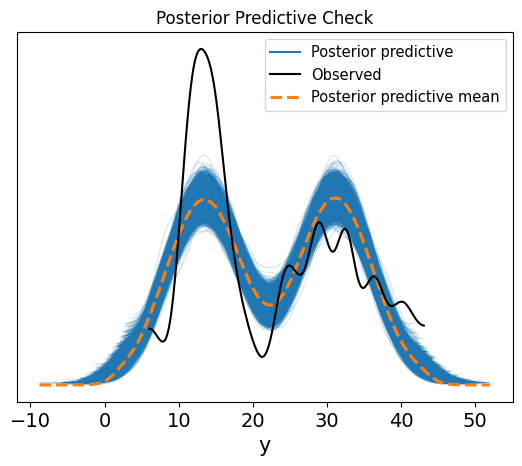

In [22]:
model_nip.predict(idata=idata_nip, kind="pps", inplace=True)

# Plot posterior predictive check
az.plot_ppc(idata_nip, group="posterior",kind="kde", data_pairs={"y": "y"})
plt.title("Posterior Predictive Check")
plt.show()

From the Bayesian Regression with non-informative prior, the actual distribution of the heating_load is the black line. We can see that most of the data lies around y=~15. This is quite higher compared to the posterior prediction. Shown in blue is the distribution of the posterior prediction. Think of it as the posibility of values of the prediction while the broken orange line is the mean of that distribution--which is the smoothened out value.

## Comparison with OLS

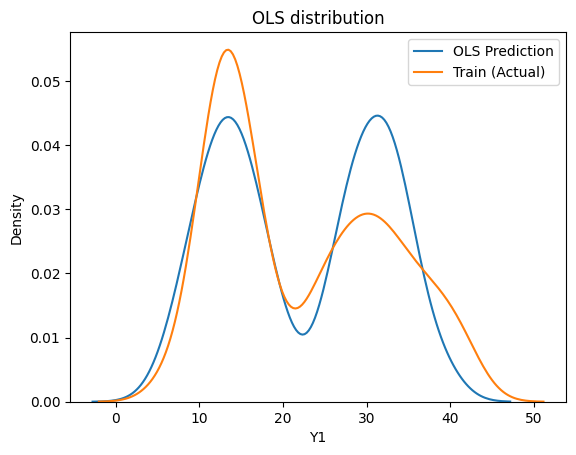

In [23]:
sns.kdeplot(y_pred, label='OLS Prediction')
sns.kdeplot(y, label='Train (Actual)')
plt.title('OLS distribution')
plt.legend()

Shown here is the same kind of distribution, but compares the original values with the non-bayesian linear regression performed earlier. Similar with the Bayesian with non-informative prior, the prediction has the same peak at near y=~15. While the original data here is shown as smoothened, the same distribution is still shown here as that of the Bayesian with non-informative prior. Thus, we can say that the Bayesian with a non-informative prior has almost the same results with it's Non-Bayesian counterpart.

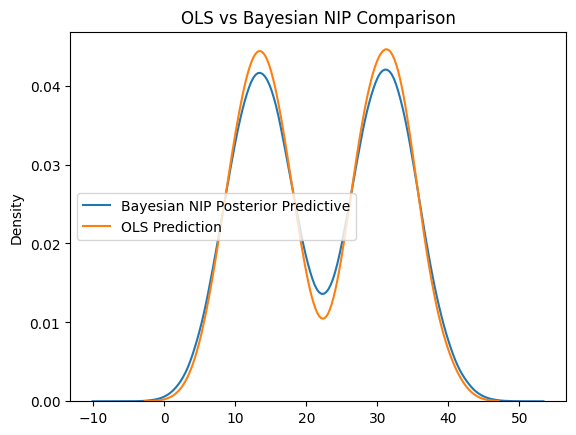

In [24]:
y_ppc_nip = idata_nip.posterior_predictive["y"].stack(draws=("chain", "draw")).values.flatten()
sns.kdeplot(y_ppc_nip, label="Bayesian NIP Posterior Predictive")
sns.kdeplot(y_pred, label='OLS Prediction')
plt.title('OLS vs Bayesian NIP Comparison')
plt.legend()

To see the actual side by side comparison, plot above shows this. As we can see, both has very similar distribution for their y predictions. This is expected as our prior is flat and can be thought of as a "smootheniner"--which this is seen as it reduced the peaks of the distribution and increased the valleys. 

### Coefficient Comparison

Appended coefficients and interval of non-bayesian and bayesian with non-informative prior.

In [25]:
results_as_html = model_ols.summary().tables[1].as_html()
ols_ci_results = pd.read_html(results_as_html, header=0, index_col=0)[0]
ols_ci_results

C:\Users\Deomary\AppData\Local\Temp\ipykernel_21320\3452130147.py:2: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  ols_ci_results = pd.read_html(results_as_html, header=0, index_col=0)[0]


,coef,std err,t,P>|t|,[0.025,0.975]
const,22.3072,0.109,204.480,0.000,22.093,22.521
wall_area,2.2527,0.114,19.817,0.000,2.030,2.476
overall_height,8.3357,0.114,73.332,0.000,8.113,8.559
orientation,-0.0261,0.109,-0.239,0.811,-0.240,0.188
glazing_area,2.6537,0.112,23.767,0.000,2.435,2.873
glazing_area_distribution,0.3158,0.112,2.829,0.005,0.097,0.535


In [26]:
mean_comparison = pd.concat(
    [
        ols_ci_results['coef'].rename(index={'const': 'Intercept'}), 
        az_summary_nip['mean']
    ], 
    axis=1
).rename(columns={'coef': 'OLS', 'mean':'Bayesian_NI'})
mean_comparison['% Diff'] = 100 * (mean_comparison['OLS'] - mean_comparison['Bayesian_NI']) /mean_comparison['OLS']
mean_comparison

,OLS,Bayesian_NI,% Diff
Intercept,22.3072,22.309,-0.008069
wall_area,2.2527,2.252,0.031074
overall_height,8.3357,8.336,-0.003599
orientation,-0.0261,-0.027,-3.448276
glazing_area,2.6537,2.653,0.026378
glazing_area_distribution,0.3158,0.315,0.253325
sigma,NaN,3.029,NaN


We can see here that the differences in coefficients are very small.

Additionally, we can see here that the Non-informative Bayesian has a sigma of 3.029 which is the square root of the noise's variance. We can see that this is almost the RMSE, thus we can interpret that our predictions, regardless of OLS or Bayesian NI, is off by around ~3 units.

### Interval Comparison

In [27]:
interval_comparison = pd.concat(
    [
        ols_ci_results[['[0.025', '0.975]']].rename(index={'const': 'Intercept'}),
        az_summary_nip[['hdi_2.5%', 'hdi_97.5%']]
    ],
    axis=1
)

interval_comparison['% Diff Lower'] = 100 * (interval_comparison['[0.025'] - interval_comparison['hdi_2.5%']) /interval_comparison['[0.025']
interval_comparison['% Diff Upper'] = 100 * (interval_comparison['0.975]'] - interval_comparison['hdi_97.5%']) /interval_comparison['0.975]']
interval_comparison

,[0.025,0.975],hdi_2.5%,hdi_97.5%,% Diff Lower,% Diff Upper
Intercept,22.093,22.521,22.100,22.524,-0.031684,-0.013321
wall_area,2.030,2.476,2.036,2.479,-0.295567,-0.121163
overall_height,8.113,8.559,8.103,8.549,0.123259,0.116836
orientation,-0.240,0.188,-0.235,0.187,2.083333,0.531915
glazing_area,2.435,2.873,2.443,2.883,-0.328542,-0.348068
glazing_area_distribution,0.097,0.535,0.102,0.540,-5.154639,-0.934579
sigma,NaN,NaN,2.882,3.183,NaN,NaN


Similar to the coefficients above, the upper and lower interval differences are negligible also.

# Bayesian Regression with Informative Prior

The same steps are performed similar to the Non-informative prior.

In [29]:
df_bayes_ip = X.copy()
df_bayes_ip['y'] = y

The main difference is here, instead of having a flat normal distribution centered around zero, we used a standard normal distribution but centered around our OLS coefficients. This somewhat encourages the model to be centered at our OLS coefficients. With a tighter variance of 1.0, this makes the model be more certain towards the OLS model.

In [28]:
ip_priors = {}
ip_priors["Intercept"] = bmb.Prior("Normal", mu=model_ols.params['const'], sigma=1.0)

for col in X.columns:
    ip_priors[col] = bmb.Prior("Normal", mu=model_ols.params[col], sigma=1.0)

Steps below are similar with the Bayesian NIP

In [30]:
model_ip = bmb.Model("y ~ " + " + ".join(X.columns[1:]),
                       data=df_bayes_ip,
                       priors=ip_priors)

idata_ip = model_ip.fit(draws=2000, tune=1000, random_seed=42, target_accept=0.9, idata_kwargs={"log_likelihood": True})

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, wall_area, overall_height, orientation, glazing_area, glazing_area_distribution]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


In [31]:
az_summary_ip = az.summary(idata_ip, hdi_prob=0.95)
display(az_summary_ip)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.027,0.078,2.873,3.178,0.001,0.001,13850.0,5896.0,1.0
Intercept,22.309,0.111,22.094,22.523,0.001,0.001,14736.0,5785.0,1.0
wall_area,2.253,0.115,2.026,2.474,0.001,0.001,12622.0,6152.0,1.0
overall_height,8.335,0.113,8.109,8.550,0.001,0.001,13303.0,6407.0,1.0
orientation,-0.027,0.109,-0.237,0.185,0.001,0.001,13561.0,5986.0,1.0
glazing_area,2.652,0.113,2.438,2.878,0.001,0.001,13298.0,6192.0,1.0
glazing_area_distribution,0.318,0.111,0.099,0.536,0.001,0.001,12526.0,6581.0,1.0


c:\Users\Deomary\AppData\Local\Programs\Python\Python312\Lib\site-packages\bambi\models.py:858: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


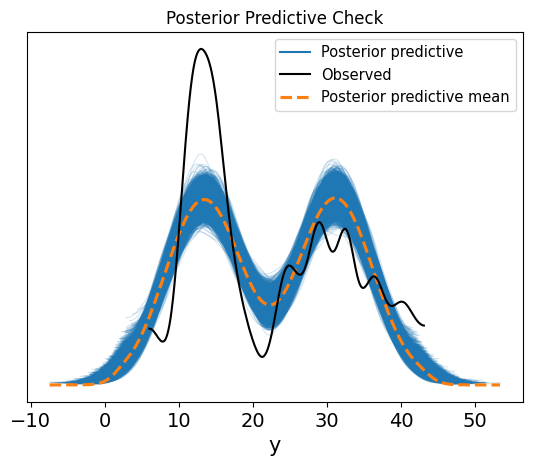

In [32]:
model_ip.predict(idata=idata_ip, kind="pps", inplace=True)

# Plot posterior predictive check
az.plot_ppc(idata_ip, group="posterior",kind="kde", data_pairs={"y": "y"})
plt.title("Posterior Predictive Check")
plt.show()

## Comparison with OLS

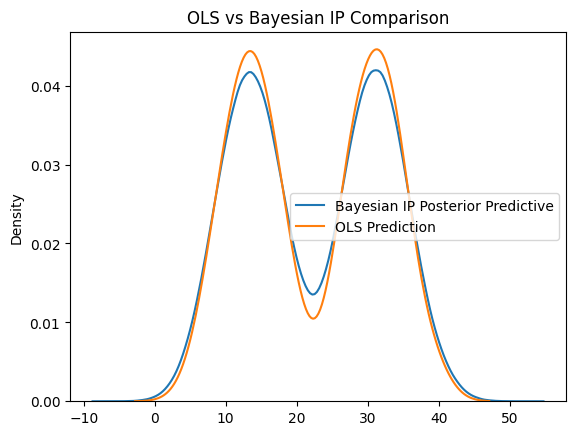

In [33]:
y_ppc_ip = idata_ip.posterior_predictive["y"].stack(draws=("chain", "draw")).values.flatten()
sns.kdeplot(y_ppc_ip, label="Bayesian IP Posterior Predictive")
sns.kdeplot(y_pred, label='OLS Prediction')
plt.title('OLS vs Bayesian IP Comparison')
plt.legend()

## Comparison with Non-Informative Prior

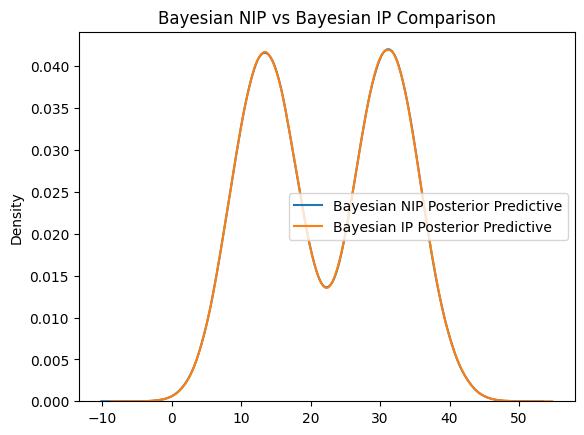

In [34]:
sns.kdeplot(y_ppc_nip, label="Bayesian NIP Posterior Predictive")
sns.kdeplot(y_ppc_ip, label="Bayesian IP Posterior Predictive")
plt.title('Bayesian NIP vs Bayesian IP Comparison')
plt.legend()

The plot shows that there is almost negligible difference in the prediction of the Bayesian NIP and Bayesian IP. This makes sense as we can see that the Bayesian NIP almost follows the OLS--something that we expect for a flat prior. And since the Bayesian IP uses a prior that follows the OLS, then they should be almost similar.

Text(0.5, 1.0, 'Posterior Coefficients: NIP vs IP')

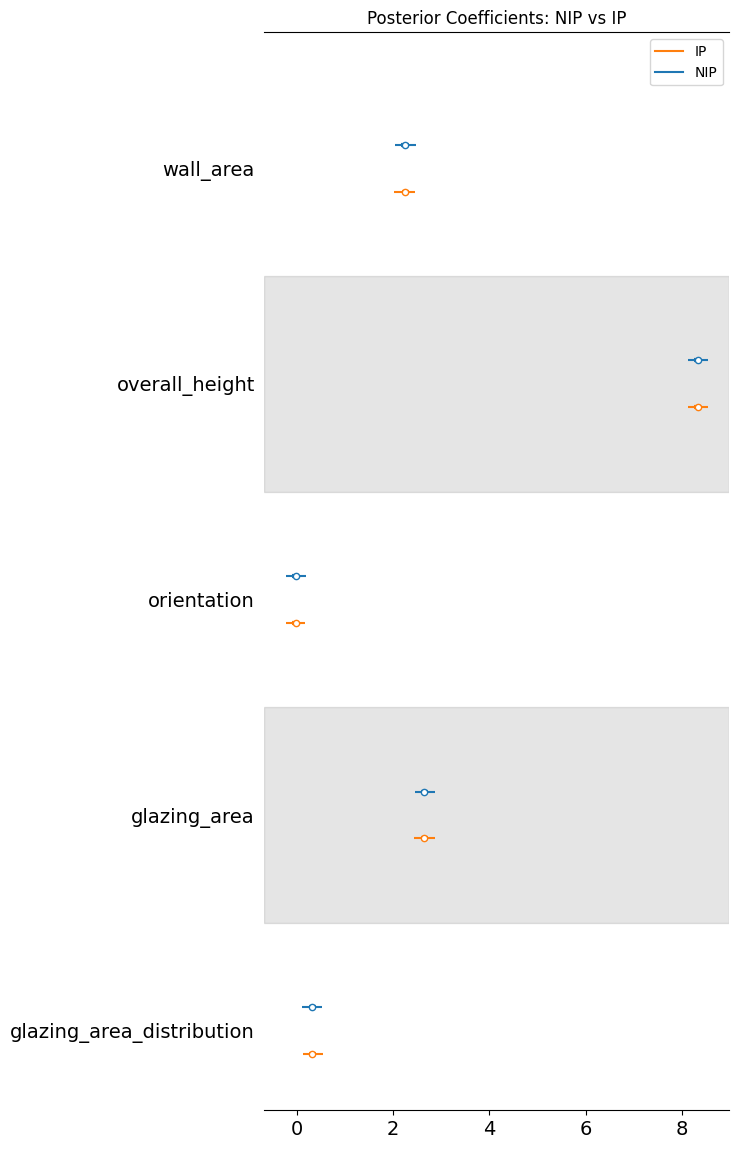

In [36]:
az.plot_forest([idata_nip, idata_ip], model_names=["NIP", "IP"], combined=True, var_names=X.columns[1:])
plt.title('Posterior Coefficients: NIP vs IP')

Based on this plot, we can see that the coefficients for both NIP and IP are almost equal.

In [37]:
mean_comparison_nip_ip = pd.concat(
    [
        az_summary_nip[['mean']].rename({'mean': 'NIP mean'}, axis=1), 
        az_summary_ip[['mean']].rename({'mean': 'IP mean'}, axis=1)
    ], 
    axis=1
)
mean_comparison_nip_ip['% Diff'] = 100 * (mean_comparison_nip_ip['NIP mean'] - mean_comparison_nip_ip['IP mean']) / mean_comparison_nip_ip['NIP mean']
mean_comparison_nip_ip

,NIP mean,IP mean,% Diff
sigma,3.029,3.027,0.066028
Intercept,22.309,22.309,0.000000
wall_area,2.252,2.253,-0.044405
overall_height,8.336,8.335,0.011996
orientation,-0.027,-0.027,-0.000000
glazing_area,2.653,2.652,0.037693
glazing_area_distribution,0.315,0.318,-0.952381


In [38]:
interval_comparison_nip_ip = pd.concat(
    [
        az_summary_nip[['hdi_2.5%', 'hdi_97.5%']].rename({'hdi_2.5%': 'NIP hdi_2.5%', 'hdi_97.5%': 'NIP hdi_97.5%'} , axis=1),
        az_summary_ip[['hdi_2.5%', 'hdi_97.5%']].rename({'hdi_2.5%': 'IP hdi_2.5%', 'hdi_97.5%': 'IP hdi_97.5%'} , axis=1),
    ],
    axis=1
)

interval_comparison_nip_ip['% Diff Lower'] = 100 * (interval_comparison_nip_ip['NIP hdi_2.5%'] - interval_comparison_nip_ip['IP hdi_2.5%']) /interval_comparison_nip_ip['NIP hdi_2.5%']
interval_comparison_nip_ip['% Diff Upper'] = 100 * (interval_comparison_nip_ip['NIP hdi_97.5%'] - interval_comparison_nip_ip['IP hdi_97.5%']) /interval_comparison_nip_ip['NIP hdi_97.5%']
interval_comparison_nip_ip

,NIP hdi_2.5%,NIP hdi_97.5%,IP hdi_2.5%,IP hdi_97.5%,% Diff Lower,% Diff Upper
sigma,2.882,3.183,2.873,3.178,0.312283,0.157085
Intercept,22.100,22.524,22.094,22.523,0.027149,0.004440
wall_area,2.036,2.479,2.026,2.474,0.491159,0.201694
overall_height,8.103,8.549,8.109,8.550,-0.074047,-0.011697
orientation,-0.235,0.187,-0.237,0.185,-0.851064,1.069519
glazing_area,2.443,2.883,2.438,2.878,0.204666,0.173430
glazing_area_distribution,0.102,0.540,0.099,0.536,2.941176,0.740741


Both tables above quantify the forest plot above.

# Cross Validation & Bootstrapping for OLS

Two (2) functions are created, one for cross validation and bootstrapping. The Cross-validation scheme uses 5 folds where 2 sets of random indices are generated (1 set for training and 1 set for validation with a ratio of 4:1). These indices define which will go to the training and which will go to the validation. We fit the model on the training data set then check the metrics on the validation then record it. We perform this 4 more times, then we return the average of those 5 metrics. For this case, that metric is the root mean squared error.

For the bootstrapping scheme, we sample 100 times where during each sampling, we get the same number of datapoints but some datapoints might get selected twice and some are not. After each sampling, we fit and test the model then record the metric. Similar to CV, the recorded metrics are averaged and that average comprises 63.2% of the returned metric. The remaining 36.8% of the metric is the metric of the original data. Similar to CV, metric selected here is still the RMSE.

In [70]:
def cross_val_rmse_aic_statsmodels(X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []
    aics = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Add constant (intercept) to X
        X_train_const = sm.add_constant(X_train)
        X_val_const = sm.add_constant(X_val)

        model = sm.OLS(y_train, X_train_const).fit()
        y_pred = model.predict(X_val_const)

        rmse = root_mean_squared_error(y_val, y_pred)
        rmses.append(rmse)

        aic = model.aic
        aics.append(aic)

    return np.mean(rmses), np.mean(aic)


def bootstrap_632_rmse_statsmodels(X, y, n_bootstraps=100):
    n = len(y)
    rmses = []

    for _ in range(n_bootstraps):
        # Sample with replacement (bootstrap)
        X_bs, y_bs = resample(X, y, replace=True, random_state=None)
        
        # Add constant
        X_bs_const = sm.add_constant(X_bs)
        model = sm.OLS(y_bs, X_bs_const).fit()
        
        # Predict on the original data
        X_full_const = sm.add_constant(X, has_constant='add')
        y_pred = model.predict(X_full_const)
        
        rmse = root_mean_squared_error(y, y_pred)
        rmses.append(rmse)

    # Also compute in-sample RMSE on full data
    X_const = sm.add_constant(X, has_constant='add')
    model_full = sm.OLS(y, X_const).fit()
    y_pred_full = model_full.predict(X_const)
    in_sample_rmse = root_mean_squared_error(y, y_pred_full)

    # Compute .632 bootstrap estimate
    return 0.368 * in_sample_rmse + 0.632 * np.mean(rmses)

We have 5 features in the model, namely overall_height, glazing_area, wall_area, glazing_area_distribution, & orientation. This are arranged in terms of their OLS coefficients from highest to lower, meaning overall_height is the most impactful while orientation is the least. What will happen here is that we start with only one feature to predict the target which is the heating_load. We then record the RMSE for both Cross Validation and Bootstrapping. Next, we add the next most impactful feature, the re-perform everything until we have recorded the metrics when using the whole set of features.

We are interested to see what happens to the model while we increase the number of features used. One might naively think that using more features would make the model better but we will see.

Just a note here that while not explicitly shown, our models still incorporates a bias/intercept term.

In [71]:
predictors = model_ols.params.sort_values(ascending=False).drop('const').index.to_list()
cv_rmses = []
cv_aics = []
boot_rmses = []
complexity = []

for i in range(1, len(predictors)+1):
    selected_features = predictors[:i]
    X_subset = X[selected_features].values

    cv_rmse, cv_aic = cross_val_rmse_aic_statsmodels(X_subset, y.values, k=5)
    boot_rmse = bootstrap_632_rmse_statsmodels(X_subset, y.values)

    cv_rmses.append(cv_rmse)
    cv_aics.append(cv_aic)
    boot_rmses.append(boot_rmse)
    complexity.append(i)

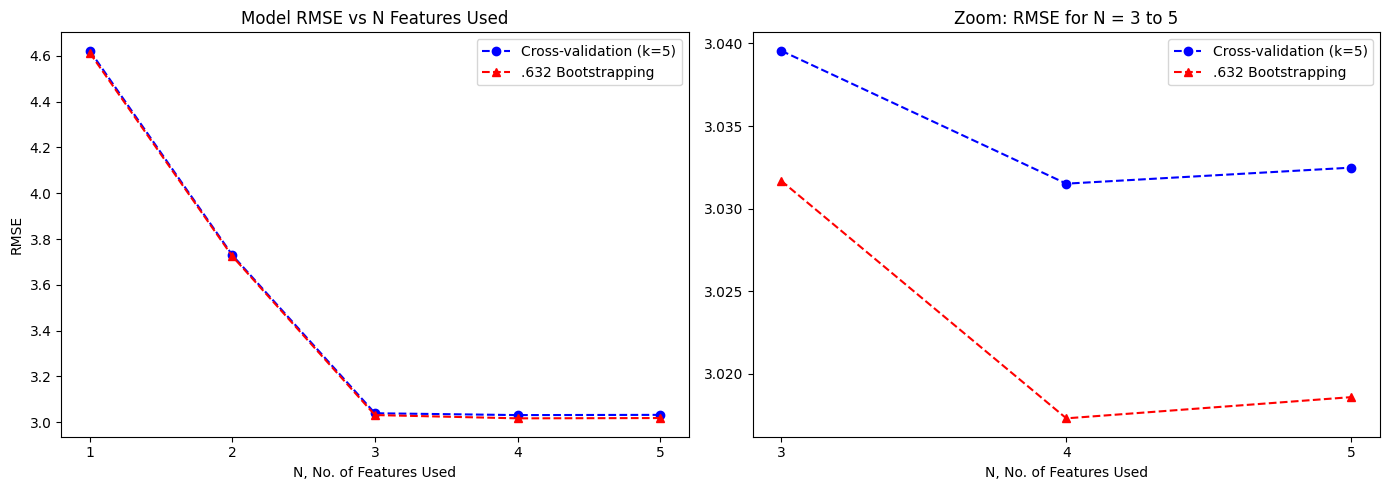

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(complexity, cv_rmses, 'b--o', label='Cross-validation (k=5)')
axes[0].plot(complexity, boot_rmses, 'r--^', label='.632 Bootstrapping')
axes[0].set_xticks(complexity)
axes[0].set_xlabel('N, No. of Features Used')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].set_title('Model RMSE vs N Features Used')

axes[1].plot(complexity[-3:], cv_rmses[-3:], 'b--o', label='Cross-validation (k=5)')
axes[1].plot(complexity[-3:], boot_rmses[-3:], 'r--^', label='.632 Bootstrapping')
axes[1].set_xticks(complexity[-3:])
axes[1].set_xlabel('N, No. of Features Used')
axes[1].legend()
axes[1].set_title('Zoom: RMSE for N = 3 to 5')

plt.tight_layout()
plt.show()

Shown here are two plots, but they are essentially the same. The left plot is the plot for all N=5 number of features while the right plot is a zoomed version to see the differences clearly.

The left plot shows that using both cross-validation and bootstrapping has the same trend. Increasing the number of features used for the model decreases the RMSE (which is better). But when zooming the results, we can see that the minimum RMSE happens at N=4, where the orientation feature is disregarded. This means that using unnecessary features actually makes our models worse! This solidifies our claim previously that using orientation does not significantly help our model as seen from its p-value that which is greater than 0.05. While it does worsen the model, it only does it by a small margin and in our case is considered insignificant. Nevertheless, it is a better call to drop this feature in our model.

# Cross Validation for Bayesian

The CV scheme here is similar with the CV scheme described in the OLS. We then use the prior prediction to calculate the RMSE.

In [42]:
def bayesian_cross_val_rmse(X, y, features, k=5, draws=1000, tune=1000):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmses = []

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        df_train = pd.DataFrame(X_train, columns=features)
        df_train['y'] = y_train
        df_val = pd.DataFrame(X_val, columns=features)
        df_val['y'] = y_val

        model = bmb.Model("y ~ " + " + ".join(features), data=df_train)
        idata = model.fit(draws=draws, tune=tune, random_seed=42, progressbar=False)

        # Predict on validation data
        df_val["y"] = y_val  # needed for ArviZ PPC pairing
        preds = model.predict(idata=idata, data=df_val, kind="response", inplace=False).posterior_predictive["y"].mean(dim=("chain", "draw")).values
        # print(type(preds))
        # preds_1d = preds.values
        rmse = root_mean_squared_error(y_val, preds)
        rmses.append(rmse)

    return np.mean(rmses)

Here, we not only store the RMSE for the CV, but also the 

In [ ]:
predictors = model_ols.params.sort_values(ascending=False).drop('const').index.to_list()
cv_bayes_rmses = []
waic_scores = []
complexity = []

for i in range(1, len(predictors)+1):
    print(f'Performing i={i}')
    selected_features = predictors[:i]
    X_subset = X[selected_features].values
    y_array = y.values

    # CV RMSE for Bayesian
    cv_rmse = bayesian_cross_val_rmse(X_subset, y_array, selected_features)
    cv_bayes_rmses.append(cv_rmse)
    
    # For WAIC/LOO on full data
    df_full = pd.DataFrame(X_subset, columns=selected_features)
    df_full['y'] = y_array
    model = bmb.Model("y ~ " + " + ".join(selected_features), data=df_full)
    idata = model.fit(draws=1000, tune=1000, random_seed=42, idata_kwargs={"log_likelihood": True}, progressbar=False)

    waic_result = az.waic(idata)
    waic_scores.append(waic_result.elpd_waic)
    
    complexity.append(i)

Initializing NUTS using jitter+adapt_diag...


Performing i=1


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, 

Performing i=2


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing

...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_00

Performing i=4


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area, glazing_area_distribution]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area, glazing_area_distribution]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area, glazing_area_distribution]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wa

Performing i=5


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area, glazing_area_distribution, orientation]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area, glazing_area_distribution, orientation]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 17 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, overall_height, glazing_area, wall_area, glazing_area_distribution, orientation]
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Inte

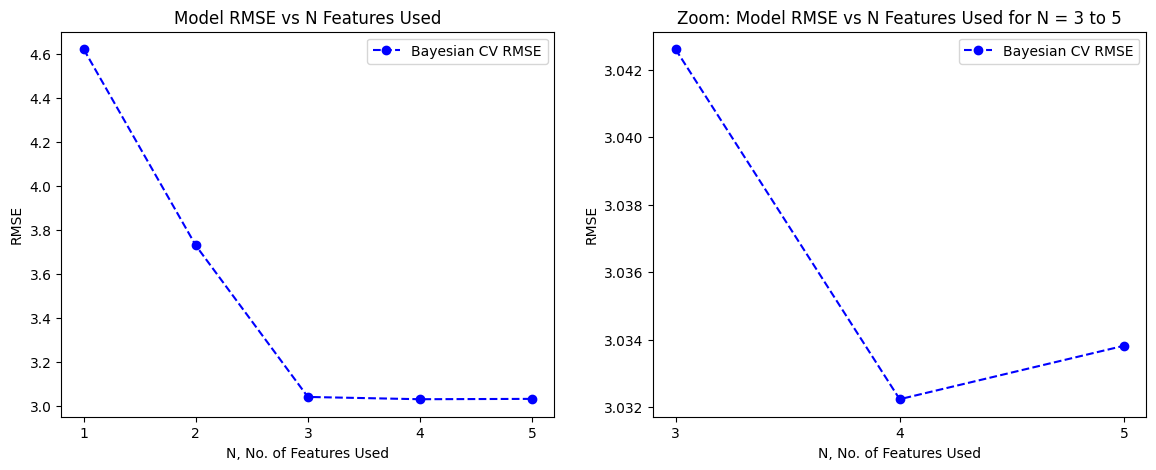

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(complexity, cv_bayes_rmses, 'b--o', label='Bayesian CV RMSE')
axes[0].set_xticks(complexity)
axes[0].set_xlabel('N, No. of Features Used')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].set_title('Model RMSE vs N Features Used')

axes[1].plot(complexity[2:], cv_bayes_rmses[2:], 'b--o', label='Bayesian CV RMSE')
axes[1].set_xticks(complexity[2:])
axes[1].set_xlabel('N, No. of Features Used')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].set_title('Zoom: Model RMSE vs N Features Used for N = 3 to 5')

plt.show()

Here we calculated for the Watanabe-Akaike Information Criterion (WAIC) which is a bayesian method for comparison and the Bayesian equaivalent of AIC. However due to the way WAIC is calculated, this is different from the AIC. Hence, we multiply it by -2. The goal here is not to compare AIC and WAIC directly but have them in the same scale to see the trend. Additionally, we subtract an arbitrary value to the WAIC to shift it closer to AIC. This is just to make the plots closes to each other and see the trend. In this case, we subtracted 750.

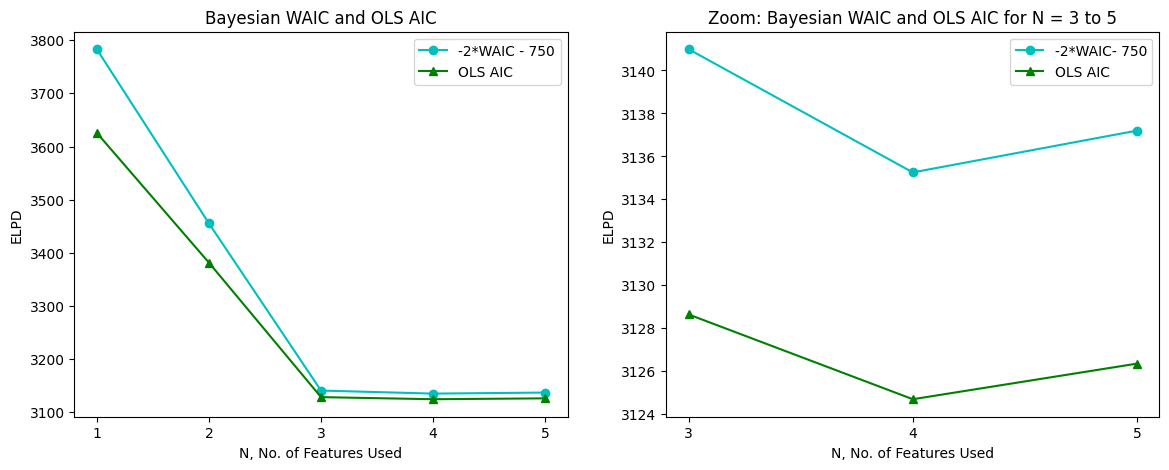

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

waic_scores_trans = [ score * -2 - 750 for score in waic_scores]

axes[0].plot(complexity, waic_scores_trans, 'c-o', label='-2*WAIC - 750')
axes[0].plot(complexity, cv_aics, 'g-^', label='OLS AIC')
axes[0].set_xticks(complexity)
axes[0].set_xlabel('N, No. of Features Used')
axes[0].set_ylabel('ELPD')
axes[0].legend()
axes[0].set_title('Bayesian WAIC and OLS AIC')

axes[1].plot(complexity[2:], waic_scores_trans[2:], 'c-o', label='-2*WAIC- 750')
axes[1].plot(complexity[2:], cv_aics[2:], 'g-^', label='OLS AIC')
axes[1].set_xticks(complexity[2:])
axes[1].set_xlabel('N, No. of Features Used')
axes[1].set_ylabel('ELPD')
axes[1].legend()
axes[1].set_title('Zoom: Bayesian WAIC and OLS AIC for N = 3 to 5')

plt.show()

Here we can see that both WAIC for Bayesian and AIC for OLS tells the same story. The best model is the one that disregards the orientation feature as it not only adds complexity and noise but also weakens the generalization capability of the model.

Ultimately, the best model for Bayesian (and is applicable for the OLS) is the model that uses the Top 4 most impactful features. While there is a slight margin of difference from the Top 3 to the Top 4 features used, using Top 4 is not a bad idea and still helps squeeze out the extra generalization capability.

# Conclusion

The energy efficiency dataset from the UC Irvine Machine Learning Repository is used for this exercise which has two continuous variables, but only the heating_load was analyzed. Only 5 selected features where used where features that could impose multicollinearity were dropped. These are then scaled using Standard Scaler.

Ordinary Least Squares Regression was performed where the coefficients (with bias) are determined together with the 95% confidence intervals. Upon seeing the p-values, there is one feature out of the five features that is observed to not statistically affect the model.

Bayesian Regression with a flat Non-informative Prior was then performed and is observed that there is no significant difference with the OLS other than slightly smoothing out the results.

Next, another Bayesian Regression but with a normal Informative Prior was used where this prior is a standard normal centered at the OLS results. This is also seen to be very similar with both OLS and Bayesian with NIP.

From the 3 regression models, it can be seen that the likelihood from the data is high and overwhelms any prior that is used.

For testing out different versions of the models but with increasing complexity (complexity is defined by the number of features used in the models), it is seen that by disregarding the one feature previously stated, it helps the model generalize well as shown by the RMSE and Information Criterions. This is shown by performing both Cross Validation and Bootstrapping.